# FINTAG - Model Eğitimi ve Değerlendirmesi
## XGBoost, Random Forest, CatBoost Karşılaştırması

**Hedef:** Kredi başvurularının onaylanma ihtimalini tahmin eden en iyi modeli bulmak

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    f1_score, precision_score, recall_score, roc_curve, auc
)
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import warnings

# Notebook çıktısında gereksiz uyarıları gizle
warnings.filterwarnings('ignore')

print('Tum kutuphaneler yuklendi')

Tum kutuphaneler yuklendi


## 1. Veri Yükleme ve Hazırlık

In [42]:
# Veri setini oku (kullanici verdigi dosya yolu)
df = pd.read_csv(r"C:\Users\melek\Desktop\Muh_tas\sheet1.csv", sep=";")

# Orijinal veriyi korumak icin kopya al
df = df.copy()

# Temel kontrol: boyut, ilk satirlar, eksik veri sayisi
print(f'Veri seti sekli: {df.shape}')
print('\nIlk 5 satir:')
print(df.head())
print('\nEksik veriler:')
print(df.isnull().sum())

Veri seti sekli: (58645, 17)

Ilk 5 satir:
    id  person_age  person_income person_home_ownership  person_emp_length  \
0  262          47         110000              MORTGAGE                 11   
1  348          32          87000              MORTGAGE                  4   
2  446          33          40000              MORTGAGE                  4   
3  469          26          85000              MORTGAGE                  5   
4  583          22         250000              MORTGAGE                  4   

         loan_intent loan_grade  loan_amnt loan_int_rate loan_percent_income  \
0            MEDICAL          A      10000          7,51                0,09   
1  DEBTCONSOLIDATION          A      10000          7,51                0,11   
2           PERSONAL          A      10000          7,51                0,25   
3            MEDICAL          A      10000          7,51                0,12   
4          EDUCATION          A      10000          7,51                0,04   

  cb_pe

In [43]:
# Sutun isimlerini standardize etmek icin buyuk harfe cevir
df.columns = [col.upper() for col in df.columns]

# DataFrame yapisini ve veri tiplerini goster
print(df.info())
print('\nVeri tipi ozeti:')
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          58645 non-null  int64 
 1   PERSON_AGE                  58645 non-null  int64 
 2   PERSON_INCOME               58645 non-null  int64 
 3   PERSON_HOME_OWNERSHIP       58645 non-null  object
 4   PERSON_EMP_LENGTH           58645 non-null  int64 
 5   LOAN_INTENT                 58645 non-null  object
 6   LOAN_GRADE                  58645 non-null  object
 7   LOAN_AMNT                   58645 non-null  int64 
 8   LOAN_INT_RATE               58645 non-null  object
 9   LOAN_PERCENT_INCOME         58645 non-null  object
 10  CB_PERSON_DEFAULT_ON_FILE   58645 non-null  object
 11  CB_PERSON_CRED_HIST_LENGTH  58645 non-null  int64 
 12  LOAN_STATUS                 58645 non-null  int64 
 13  LOAN_INT_RATE (BINS)        58645 non-null  ob

In [44]:
# Kategorik ve sayisal sutunlari ayir
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f'Kategorik sutunlar ({len(categorical_cols)}): {categorical_cols}')
print(f'\nSayisal sutunlar ({len(numerical_cols)}): {numerical_cols}')

Kategorik sutunlar (9): ['PERSON_HOME_OWNERSHIP', 'LOAN_INTENT', 'LOAN_GRADE', 'LOAN_INT_RATE', 'LOAN_PERCENT_INCOME', 'CB_PERSON_DEFAULT_ON_FILE', 'LOAN_INT_RATE (BINS)', 'AGE_GROUP', 'INCOME_BRACKET']

Sayisal sutunlar (8): ['ID', 'PERSON_AGE', 'PERSON_INCOME', 'PERSON_EMP_LENGTH', 'LOAN_AMNT', 'CB_PERSON_CRED_HIST_LENGTH', 'LOAN_STATUS', 'PERSON_INCOME (BINS)']


## 2. Hedef Değişken Belirleme

In [45]:
# Hedef degiskeni secmeden once sutunlari ve olasi sinif dagilimlarini incele
print('Mevcut sutunlar:')
for i, col in enumerate(df.columns, 1):
    print(f'{i}. {col}')

print('\nSutun istatistikleri (nunique < 20):')
for col in df.columns:
    if df[col].nunique() < 20:
        print(f'\n{col} - Essiz degerler ({df[col].nunique()}):')
        print(df[col].value_counts())

Mevcut sutunlar:
1. ID
2. PERSON_AGE
3. PERSON_INCOME
4. PERSON_HOME_OWNERSHIP
5. PERSON_EMP_LENGTH
6. LOAN_INTENT
7. LOAN_GRADE
8. LOAN_AMNT
9. LOAN_INT_RATE
10. LOAN_PERCENT_INCOME
11. CB_PERSON_DEFAULT_ON_FILE
12. CB_PERSON_CRED_HIST_LENGTH
13. LOAN_STATUS
14. LOAN_INT_RATE (BINS)
15. AGE_GROUP
16. INCOME_BRACKET
17. PERSON_INCOME (BINS)

Sutun istatistikleri (nunique < 20):

PERSON_HOME_OWNERSHIP - Essiz degerler (4):
PERSON_HOME_OWNERSHIP
RENT        30594
MORTGAGE    24824
OWN          3138
OTHER          89
Name: count, dtype: int64

LOAN_INTENT - Essiz degerler (6):
LOAN_INTENT
EDUCATION            12271
MEDICAL              10934
PERSONAL             10016
VENTURE              10011
DEBTCONSOLIDATION     9133
HOMEIMPROVEMENT       6280
Name: count, dtype: int64

LOAN_GRADE - Essiz degerler (7):
LOAN_GRADE
A    20984
B    20400
C    11036
D     5034
E     1009
F      149
G       33
Name: count, dtype: int64

CB_PERSON_DEFAULT_ON_FILE - Essiz degerler (2):
CB_PERSON_DEFAULT_ON_F

In [46]:
# Hedef degiskeni belirle
if 'ID' in df.columns:
    # ID kolonu modele bilgi tasimadigi icin kaldir
    df = df.drop('ID', axis=1)

# Bu veri setinde asil hedef kolon LOAN_STATUS (13. kolon)
if 'LOAN_STATUS' in df.columns:
    target_col = 'LOAN_STATUS'
else:
    # Yedek strateji: hedef kolonu bulunamazsa son kolonu kullan
    target_col = df.columns[-1]

print(f'Hedef degisken: {target_col}')
print('\nHedef degisken dagilimi:')
print(df[target_col].value_counts())
print('\nHedef degisken yuzdeleri:')
print(df[target_col].value_counts(normalize=True) * 100)

Hedef degisken: LOAN_STATUS

Hedef degisken dagilimi:
LOAN_STATUS
0    50295
1     8350
Name: count, dtype: int64

Hedef degisken yuzdeleri:
LOAN_STATUS
0    85.761787
1    14.238213
Name: proportion, dtype: float64


## 3. Veri Ön İşleme

In [47]:
# Eksik veri kontrolu ve kolon tipine gore doldurma stratejisi
print('Eksik veriler:')
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    print(missing_data[missing_data > 0])

    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                # Kategorik kolonlarda en sik degeri kullan
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                # Sayisal kolonlarda medyan kullan
                df[col].fillna(df[col].median(), inplace=True)

    print('Eksik veriler dolduruldu')
else:
    print('Eksik veri yok')

Eksik veriler:
Eksik veri yok


In [48]:
# Kategorik kolonlari numerik forma cevir (Label Encoding)
df_encoded = df.copy()
label_encoders = {}

for col in categorical_cols:
    if col in df_encoded.columns and col != target_col:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f'{col} encode edildi ({len(le.classes_)} sinif)')

# Hedef degisken kategorik ise onu da encode et
if target_col in categorical_cols:
    le_target = LabelEncoder()
    df_encoded[target_col] = le_target.fit_transform(df_encoded[target_col].astype(str))
    label_encoders[target_col] = le_target
    print(f'{target_col} (hedef) encode edildi')

print('\nEncode sonrasi veri:')
print(df_encoded.head())

PERSON_HOME_OWNERSHIP encode edildi (4 sinif)
LOAN_INTENT encode edildi (6 sinif)
LOAN_GRADE encode edildi (7 sinif)
LOAN_INT_RATE encode edildi (362 sinif)
LOAN_PERCENT_INCOME encode edildi (61 sinif)
CB_PERSON_DEFAULT_ON_FILE encode edildi (2 sinif)
LOAN_INT_RATE (BINS) encode edildi (36 sinif)
AGE_GROUP encode edildi (6 sinif)
INCOME_BRACKET encode edildi (6 sinif)

Encode sonrasi veri:
   PERSON_AGE  PERSON_INCOME  PERSON_HOME_OWNERSHIP  PERSON_EMP_LENGTH  \
0          47         110000                      0                 11   
1          32          87000                      0                  4   
2          33          40000                      0                  4   
3          26          85000                      0                  5   
4          22         250000                      0                  4   

   LOAN_INTENT  LOAN_GRADE  LOAN_AMNT  LOAN_INT_RATE  LOAN_PERCENT_INCOME  \
0            3           0      10000            315                    9   
1       

## 4. Model Eğitimi

In [49]:
# Ozellikler (X) ve hedef (y) ayir
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

print(f'Ozellik sayisi: {X.shape[1]}')
print('Hedef degisken dagilimi:')
print(y.value_counts())
print('\nSinif dagilimi yuzdesi:')
print(y.value_counts(normalize=True) * 100)

Ozellik sayisi: 15
Hedef degisken dagilimi:
LOAN_STATUS
0    50295
1     8350
Name: count, dtype: int64

Sinif dagilimi yuzdesi:
LOAN_STATUS
0    85.761787
1    14.238213
Name: proportion, dtype: float64


In [50]:
# Veriyi egitim ve test olarak ayir
# Not: stratify kullanmak icin her sinifta en az 2 ornek olmali
test_size = 0.2
class_counts = y.value_counts()
min_class_count = class_counts.min()
n_classes = class_counts.shape[0]
n_train = int(len(y) * (1 - test_size))

use_stratify = True
if min_class_count < 2:
    use_stratify = False
    print('Uyari: En az bir sinifta tek ornek var. stratify devre disi birakildi.')
elif n_train < n_classes:
    use_stratify = False
    print('Uyari: Egitim setindeki satir sayisi sinif sayisindan az. stratify devre disi birakildi.')

stratify_arg = y if use_stratify else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42, stratify=stratify_arg
)

print(f'Egitim seti: {X_train.shape[0]} satir ({X_train.shape[0]*100/len(X):.1f}%)')
print(f'Test seti: {X_test.shape[0]} satir ({X_test.shape[0]*100/len(X):.1f}%)')
print('\nEgitim seti hedef dagilimi:')
print(y_train.value_counts())
print('\nTest seti hedef dagilimi:')
print(y_test.value_counts())

Egitim seti: 46916 satir (80.0%)
Test seti: 11729 satir (20.0%)

Egitim seti hedef dagilimi:
LOAN_STATUS
0    40236
1     6680
Name: count, dtype: int64

Test seti hedef dagilimi:
LOAN_STATUS
0    10059
1     1670
Name: count, dtype: int64


In [51]:
# 1) XGBoost modeli egit
print('\n' + '='*60)
print('XGBoost modeli egitiliyor...')
print('='*60)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print('XGBoost egitimi tamamlandi')


XGBoost modeli egitiliyor...
XGBoost egitimi tamamlandi


In [52]:
# 2) Random Forest modeli egit
print('\n' + '='*60)
print('Random Forest modeli egitiliyor...')
print('='*60)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print('Random Forest egitimi tamamlandi')


Random Forest modeli egitiliyor...
Random Forest egitimi tamamlandi


In [53]:
# 3) CatBoost modeli egit
print('\n' + '='*60)
print('CatBoost modeli egitiliyor...')
print('='*60)

catboost_model = CatBoostClassifier(
    iterations=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
catboost_pred = catboost_model.predict(X_test)
catboost_pred_proba = catboost_model.predict_proba(X_test)[:, 1]

print('CatBoost egitimi tamamlandi')


CatBoost modeli egitiliyor...
CatBoost egitimi tamamlandi


## 5. Model Değerlendirmesi

In [54]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Tek bir modelin temel siniflandirma metriklerini hesaplar."""
    f1 = f1_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    metrics = {
        'Model': model_name,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'ROC-AUC': roc_auc
    }

    print(f'\n{model_name} performansi:')
    print('='*50)
    print(f'F1-Score:  {f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'ROC-AUC:   {roc_auc:.4f}')
    print('='*50)

    print('\nConfusion Matrix:')
    print(confusion_matrix(y_true, y_pred))

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred))

    return metrics

# Tum modellerin metriklerini tek tabloda toplamak icin liste
results = []
results.append(evaluate_model(y_test, xgb_pred, xgb_pred_proba, 'XGBoost'))
results.append(evaluate_model(y_test, rf_pred, rf_pred_proba, 'Random Forest'))
results.append(evaluate_model(y_test, catboost_pred, catboost_pred_proba, 'CatBoost'))


XGBoost performansi:
F1-Score:  0.8085
Precision: 0.9404
Recall:    0.7090
ROC-AUC:   0.9538

Confusion Matrix:
[[9984   75]
 [ 486 1184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.94      0.71      0.81      1670

    accuracy                           0.95     11729
   macro avg       0.95      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729


Random Forest performansi:
F1-Score:  0.7772
Precision: 0.9205
Recall:    0.6725
ROC-AUC:   0.9301

Confusion Matrix:
[[9962   97]
 [ 547 1123]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.92      0.67      0.78      1670

    accuracy                           0.95     11729
   macro avg       0.93      0.83      0.87     11729
weighted avg       0.94      0.95      0.94     11729


CatBoost pe

In [55]:
# Model sonuclarini DataFrame'e cevir ve karsilastir
results_df = pd.DataFrame(results)
print('\nModel karsilastirma tablosu:')
print(results_df.to_string(index=False))

# F1-Score'a gore en iyi modeli bul
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_f1 = results_df.loc[best_model_idx, 'F1-Score']

print(f'\nEn iyi model: {best_model_name}')
print(f'F1-Score: {best_f1:.4f}')


Model karsilastirma tablosu:
        Model  F1-Score  Precision   Recall  ROC-AUC
      XGBoost  0.808467   0.940429 0.708982 0.953822
Random Forest  0.777163   0.920492 0.672455 0.930111
     CatBoost  0.803160   0.941982 0.700000 0.940360

En iyi model: XGBoost
F1-Score: 0.8085


In [56]:
# SADECE XGBoost icin threshold analizi
xgb_proba = xgb_pred_proba

# Farkli threshold degerlerinde Precision-Recall tablosu olustur
threshold_list = np.arange(0.20, 0.81, 0.05)
threshold_results = []

for t in threshold_list:
    y_pred_t = (xgb_proba >= t).astype(int)
    precision_t = precision_score(y_test, y_pred_t, zero_division=0)
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    f1_t = f1_score(y_test, y_pred_t, zero_division=0)
    threshold_results.append({
        'Threshold': round(float(t), 2),
        'Precision': precision_t,
        'Recall': recall_t,
        'F1-Score': f1_t
    })

threshold_df = pd.DataFrame(threshold_results)
print('XGBoost threshold performans tablosu:')
print(threshold_df.to_string(index=False))

# Recall oncelikli secim: Recall >= 0.90 olanlar arasinda Precision en yuksek threshold
recall_target = 0.90
candidates = threshold_df[threshold_df['Recall'] >= recall_target]

if not candidates.empty:
    best_row = candidates.sort_values(['Precision', 'Threshold'], ascending=[False, False]).iloc[0]
    suggested_threshold = float(best_row['Threshold'])
    print(f"\nXGBoost icin onerilen threshold (Recall >= {recall_target:.2f}): {suggested_threshold:.2f}")
else:
    # Hedef recall bulunamazsa recall'i en yuksek yapan threshold'u sec
    best_row = threshold_df.sort_values(['Recall', 'Precision'], ascending=[False, False]).iloc[0]
    suggested_threshold = float(best_row['Threshold'])
    print(f"\nXGBoost icin Recall hedefi {recall_target:.2f} yakalanamadi. En iyi recall threshold'u: {suggested_threshold:.2f}")

# Onerilen threshold ile metrikleri yazdir
y_pred_suggested = (xgb_proba >= suggested_threshold).astype(int)
precision_s = precision_score(y_test, y_pred_suggested, zero_division=0)
recall_s = recall_score(y_test, y_pred_suggested, zero_division=0)
f1_s = f1_score(y_test, y_pred_suggested, zero_division=0)

print('\nXGBoost - onerilen threshold ile metrikler:')
print(f'Precision: {precision_s:.4f}')
print(f'Recall:    {recall_s:.4f}')
print(f'F1-Score:  {f1_s:.4f}')

# Karsilastirma: varsayilan threshold 0.50
y_pred_default = (xgb_proba >= 0.50).astype(int)
precision_d = precision_score(y_test, y_pred_default, zero_division=0)
recall_d = recall_score(y_test, y_pred_default, zero_division=0)
f1_d = f1_score(y_test, y_pred_default, zero_division=0)

print('\nXGBoost - varsayilan threshold (0.50) metrikleri:')
print(f'Precision: {precision_d:.4f}')
print(f'Recall:    {recall_d:.4f}')
print(f'F1-Score:  {f1_d:.4f}')

XGBoost threshold performans tablosu:
 Threshold  Precision   Recall  F1-Score
      0.20   0.773226 0.802395  0.787540
      0.25   0.822306 0.781437  0.801351
      0.30   0.866576 0.762275  0.811086
      0.35   0.895115 0.746108  0.813847
      0.40   0.919575 0.725749  0.811245
      0.45   0.929907 0.714970  0.808395
      0.50   0.940429 0.708982  0.808467
      0.55   0.950407 0.700000  0.806207
      0.60   0.954844 0.696407  0.805402
      0.65   0.958264 0.687425  0.800558
      0.70   0.959562 0.682036  0.797340
      0.75   0.961872 0.664671  0.786119
      0.80   0.962264 0.641317  0.769673

XGBoost icin Recall hedefi 0.90 yakalanamadi. En iyi recall threshold'u: 0.20

XGBoost - onerilen threshold ile metrikler:
Precision: 0.7732
Recall:    0.8024
F1-Score:  0.7875

XGBoost - varsayilan threshold (0.50) metrikleri:
Precision: 0.9404
Recall:    0.7090
F1-Score:  0.8085


## 6. Threshold Ayari (Sadece XGBoost)
Bu bolum yalnizca XGBoost modelinin olasilik ciktilarinda threshold degerini degistirerek Recall degerini artirmayi test eder.
Pozitif vakalari kacirmamak istedigimiz senaryolarda threshold dusurulur; buna karsilik Precision bir miktar dusebilir.

## 7. ROC Egrileri Karsilastirmasi

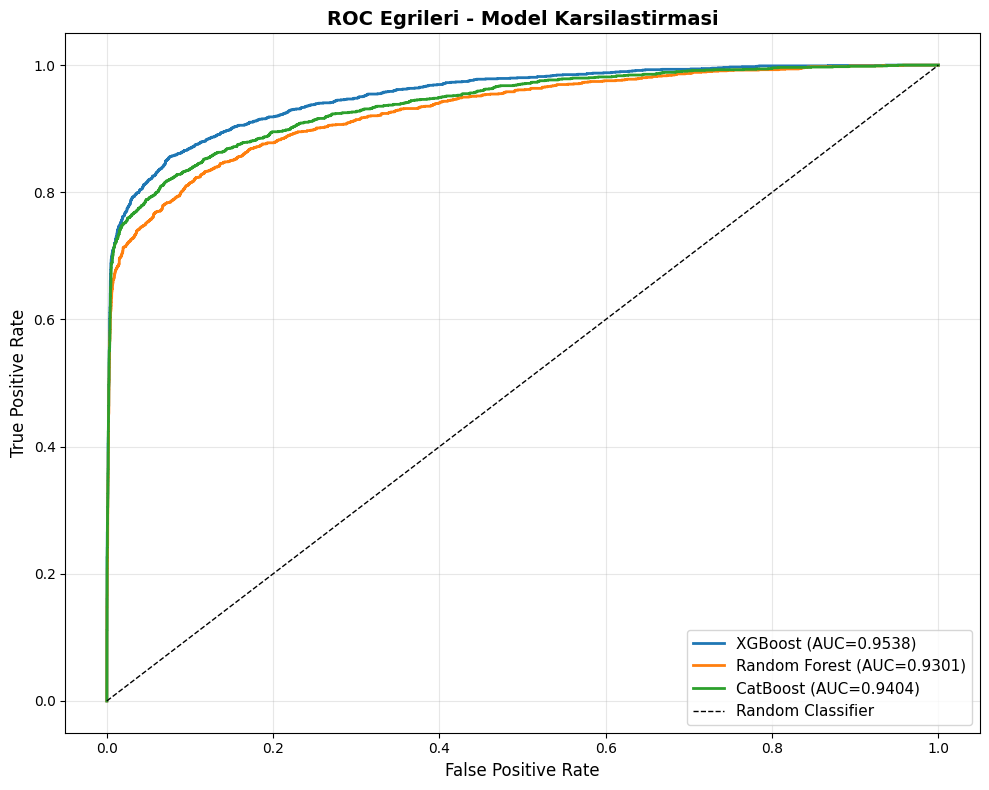

ROC egrileri cizildi


In [57]:
# ROC egirilerini ayni grafikte ciz
plt.figure(figsize=(10, 8))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.4f})', linewidth=2)

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.4f})', linewidth=2)

# CatBoost ROC
fpr_cat, tpr_cat, _ = roc_curve(y_test, catboost_pred_proba)
auc_cat = auc(fpr_cat, tpr_cat)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC={auc_cat:.4f})', linewidth=2)

# Referans cizgisi (rastgele siniflayici)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Egrileri - Model Karsilastirmasi', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('ROC egrileri cizildi')

## 8. Ozellik Onemliligi


XGBoost - En onemli 10 ozellik:
                  Feature  Importance
5              LOAN_GRADE    0.421096
8     LOAN_PERCENT_INCOME    0.231132
2   PERSON_HOME_OWNERSHIP    0.141234
4             LOAN_INTENT    0.058172
1           PERSON_INCOME    0.038972
3       PERSON_EMP_LENGTH    0.027034
7           LOAN_INT_RATE    0.016171
13         INCOME_BRACKET    0.013493
0              PERSON_AGE    0.012206
6               LOAN_AMNT    0.009496


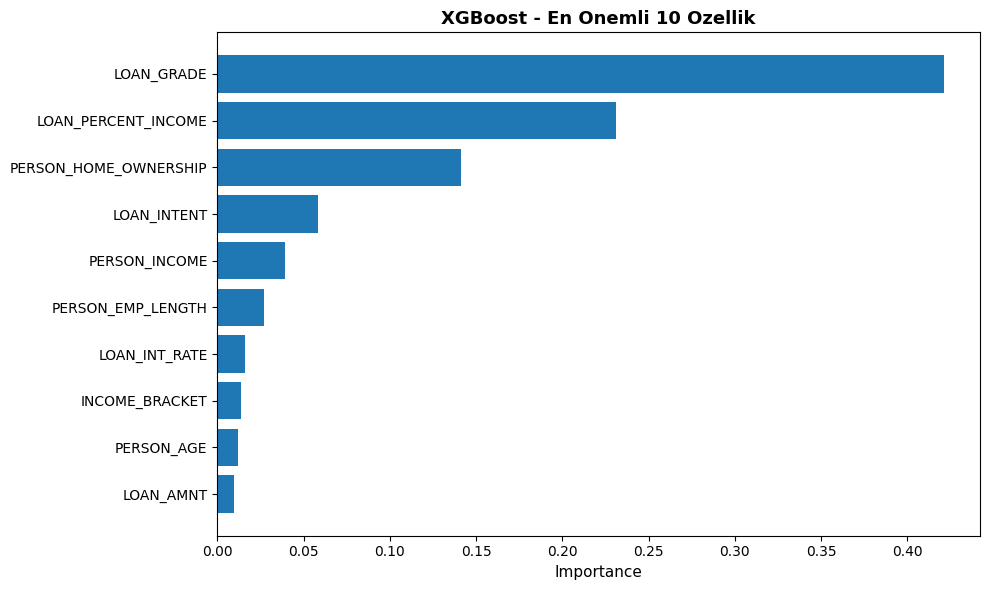

In [58]:
# XGBoost modelinin ozellik onemliliklerini hesapla
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nXGBoost - En onemli 10 ozellik:')
print(feature_importance_xgb.head(10))

# İlk 10 ozelligi yatay bar grafik olarak goster
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_xgb['Feature'].head(10), feature_importance_xgb['Importance'].head(10))
plt.xlabel('Importance', fontsize=11)
plt.title('XGBoost - En Onemli 10 Ozellik', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Random Forest - En onemli 10 ozellik:
                  Feature  Importance
8     LOAN_PERCENT_INCOME    0.271102
5              LOAN_GRADE    0.200946
2   PERSON_HOME_OWNERSHIP    0.112659
1           PERSON_INCOME    0.071655
7           LOAN_INT_RATE    0.067925
6               LOAN_AMNT    0.061524
11   LOAN_INT_RATE (BINS)    0.050120
14   PERSON_INCOME (BINS)    0.037944
4             LOAN_INTENT    0.037165
3       PERSON_EMP_LENGTH    0.037061


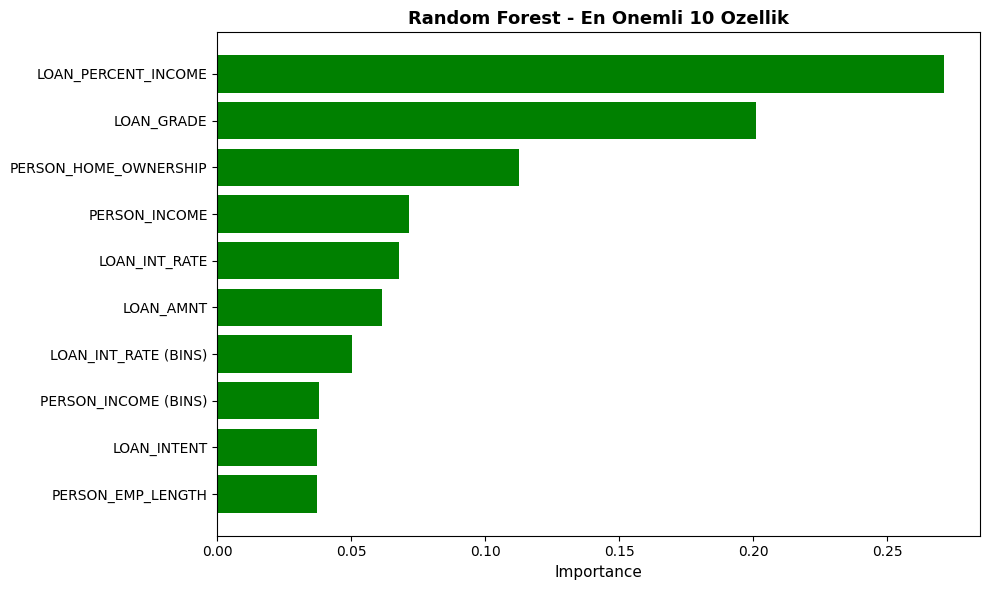

In [59]:
# Random Forest modelinin ozellik onemliliklerini hesapla
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nRandom Forest - En onemli 10 ozellik:')
print(feature_importance_rf.head(10))

# İlk 10 ozelligi yatay bar grafik olarak goster
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_rf['Feature'].head(10), feature_importance_rf['Importance'].head(10), color='green')
plt.xlabel('Importance', fontsize=11)
plt.title('Random Forest - En Onemli 10 Ozellik', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Model Kaydetme

In [60]:
import joblib
import os

# Kaydedilecek klasoru olustur
model_dir = r'C:\Users\melek\Desktop\MÜH_TAS\final projesi\FINTAG\ml_models\models'
os.makedirs(model_dir, exist_ok=True)

# Egitilen modelleri diske yaz
joblib.dump(xgb_model, os.path.join(model_dir, 'xgboost_model.pkl'))
joblib.dump(rf_model, os.path.join(model_dir, 'random_forest_model.pkl'))
joblib.dump(catboost_model, os.path.join(model_dir, 'catboost_model.pkl'))

print('\nTum modeller kaydedildi:')
print(model_dir)
print('   - xgboost_model.pkl')
print('   - random_forest_model.pkl')
print('   - catboost_model.pkl')

# Tahminde kolon sirasi bozulmamasi icin feature adlarini da kaydet
feature_names = {'features': list(X_train.columns)}
joblib.dump(feature_names, os.path.join(model_dir, 'feature_names.pkl'))
print('   - feature_names.pkl')


Tum modeller kaydedildi:
C:\Users\melek\Desktop\MÜH_TAS\final projesi\FINTAG\ml_models\models
   - xgboost_model.pkl
   - random_forest_model.pkl
   - catboost_model.pkl
   - feature_names.pkl


## Ozet

In [61]:
# Egitim surecinin toplu ozetini yazdir
print('\n' + '='*70)
print('FINTAG MODEL EGITIM OZETI')
print('='*70)
print('\nVeri seti bilgileri:')
print(f'   - Toplam satir: {len(df_encoded):,}')
print(f'   - Toplam ozellik: {X.shape[1]}')
print(f'   - Egitim seti: {X_train.shape[0]:,} satir')
print(f'   - Test seti: {X_test.shape[0]:,} satir')

print('\nEgitilen modeller:')
print('   1. XGBoost')
print('   2. Random Forest')
print('   3. CatBoost')

print(f'\nEn iyi model: {best_model_name}')
print(results_df.to_string(index=False))

print(f'\nModellerin kayit yolu: {model_dir}')
print('\nTum modeller ve feature adlari pickle formatinda kaydedildi.')
print('='*70)


FINTAG MODEL EGITIM OZETI

Veri seti bilgileri:
   - Toplam satir: 58,645
   - Toplam ozellik: 15
   - Egitim seti: 46,916 satir
   - Test seti: 11,729 satir

Egitilen modeller:
   1. XGBoost
   2. Random Forest
   3. CatBoost

En iyi model: XGBoost
        Model  F1-Score  Precision   Recall  ROC-AUC
      XGBoost  0.808467   0.940429 0.708982 0.953822
Random Forest  0.777163   0.920492 0.672455 0.930111
     CatBoost  0.803160   0.941982 0.700000 0.940360

Modellerin kayit yolu: C:\Users\melek\Desktop\MÜH_TAS\final projesi\FINTAG\ml_models\models

Tum modeller ve feature adlari pickle formatinda kaydedildi.


## 10. Ek Modeller (Sona Eklendi)
Bu bolumde ek olarak LightGBM, MLP, SVM ve Naive Bayes modelleri egitilir ve mevcut evaluate_model fonksiyonu ile degerlendirilir.
Not: MLP ve SVM icin olcekleme (StandardScaler) kullanilir.

In [6]:
# Ek modeller: LightGBM, MLP, SVM, Naive Bayes
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# Kernel sifirlandiginda yardimci fonksiyon yoksa burada olustur
if 'evaluate_model' not in globals():
    def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
        f1 = f1_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        roc_auc = roc_auc_score(y_true, y_pred_proba)

        metrics = {
            'Model': model_name,
            'F1-Score': f1,
            'Precision': precision,
            'Recall': recall,
            'ROC-AUC': roc_auc
        }

        print(f'\n{model_name} performansi:')
        print('='*50)
        print(f'F1-Score:  {f1:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall:    {recall:.4f}')
        print(f'ROC-AUC:   {roc_auc:.4f}')
        print('='*50)
        print('\nConfusion Matrix:')
        print(confusion_matrix(y_true, y_pred))
        print('\nClassification Report:')
        print(classification_report(y_true, y_pred))
        return metrics

# Eger split degiskenleri yoksa bu hucre kendi basina veriyi hazirlar
required_vars = ['X_train', 'X_test', 'y_train', 'y_test']
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    print('Uyari: Split degiskenleri eksik. Hucre kendi icinde veri hazirliyor...')
    csv_path = r"C:\Users\melek\Desktop\Muh_tas\sheet1.csv"
    df_local = pd.read_csv(csv_path, sep=';').copy()
    df_local.columns = [col.upper() for col in df_local.columns]

    if 'ID' in df_local.columns:
        df_local = df_local.drop('ID', axis=1)

    if 'LOAN_STATUS' in df_local.columns:
        target_local = 'LOAN_STATUS'
    else:
        target_local = df_local.columns[-1]

    # Eksik veri doldurma
    for col in df_local.columns:
        if df_local[col].isnull().sum() > 0:
            if df_local[col].dtype == 'object':
                df_local[col].fillna(df_local[col].mode()[0], inplace=True)
            else:
                df_local[col].fillna(df_local[col].median(), inplace=True)

    # Kategorik encode
    df_encoded_local = df_local.copy()
    categorical_local = df_encoded_local.select_dtypes(include=['object']).columns.tolist()
    for col in categorical_local:
        le = LabelEncoder()
        df_encoded_local[col] = le.fit_transform(df_encoded_local[col].astype(str))

    X = df_encoded_local.drop(target_local, axis=1)
    y = df_encoded_local[target_local]

    test_size = 0.2
    class_counts = y.value_counts()
    min_class_count = class_counts.min()
    n_classes = class_counts.shape[0]
    n_train = int(len(y) * (1 - test_size))
    use_stratify = (min_class_count >= 2) and (n_train >= n_classes)
    stratify_arg = y if use_stratify else None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42, stratify=stratify_arg
    )

# Eger temel modellerin sonuclari yoksa burada hizlica olustur
if 'results_df' not in globals():
    print('Uyari: results_df yok. Temel modeller bu hucrede egitilecek...')
    base_results = []

    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, eval_metric='logloss'
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    base_results.append(evaluate_model(y_test, xgb_pred, xgb_pred_proba, 'XGBoost'))

    rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)
    rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]
    base_results.append(evaluate_model(y_test, rf_pred, rf_pred_proba, 'Random Forest'))

    catboost_model = CatBoostClassifier(
        iterations=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=False
    )
    catboost_model.fit(X_train, y_train)
    catboost_pred = catboost_model.predict(X_test)
    catboost_pred_proba = catboost_model.predict_proba(X_test)[:, 1]
    base_results.append(evaluate_model(y_test, catboost_pred, catboost_pred_proba, 'CatBoost'))

    results_df = pd.DataFrame(base_results)

extra_results = []

# 1) LightGBM (kuruluysa)
try:
    from lightgbm import LGBMClassifier

    lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42
    )
    lgbm_model.fit(X_train, y_train)
    lgbm_pred = lgbm_model.predict(X_test)
    lgbm_pred_proba = lgbm_model.predict_proba(X_test)[:, 1]
    extra_results.append(evaluate_model(y_test, lgbm_pred, lgbm_pred_proba, 'LightGBM'))
except Exception as e:
    print('LightGBM calistirilamadi. Paket yoksa su komutla kurabilirsin: pip install lightgbm')
    print(f'Detay: {e}')

# 2) MLP (olcekleme gerekli)
mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ))
])
mlp_pipeline.fit(X_train, y_train)
mlp_pred = mlp_pipeline.predict(X_test)
mlp_pred_proba = mlp_pipeline.predict_proba(X_test)[:, 1]
extra_results.append(evaluate_model(y_test, mlp_pred, mlp_pred_proba, 'MLP'))

# 3) SVM (RBF)
USE_SVM_SUBSAMPLE = True
SVM_TRAIN_SIZE = 15000
if USE_SVM_SUBSAMPLE and len(X_train) > SVM_TRAIN_SIZE:
    X_svm = X_train.sample(n=SVM_TRAIN_SIZE, random_state=42)
    y_svm = y_train.loc[X_svm.index]
    print(f'SVM egitimi hizlandirma: {len(X_train)} yerine {len(X_svm)} satir kullanildi.')
else:
    X_svm = X_train
    y_svm = y_train

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=1.0, kernel='rbf', probability=True, random_state=42))
])
svm_pipeline.fit(X_svm, y_svm)
svm_pred = svm_pipeline.predict(X_test)
svm_pred_proba = svm_pipeline.predict_proba(X_test)[:, 1]
extra_results.append(evaluate_model(y_test, svm_pred, svm_pred_proba, 'SVM (RBF)'))

# 4) Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_pred_proba = nb_model.predict_proba(X_test)[:, 1]
extra_results.append(evaluate_model(y_test, nb_pred, nb_pred_proba, 'Naive Bayes'))

# Ek modellerin toplu tablosu
extra_results_df = pd.DataFrame(extra_results)
print('\nEk model karsilastirma tablosu:')
print(extra_results_df.to_string(index=False))
best_extra_idx = extra_results_df['F1-Score'].idxmax()
best_extra_model = extra_results_df.loc[best_extra_idx, 'Model']
print(f'\nEk modellerde en iyi F1-Score: {best_extra_model}')

# Tum modelleri tek tabloda birlestir (mevcut + ek)
all_models_df = pd.concat([results_df, extra_results_df], ignore_index=True)
all_models_df = all_models_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
print('\nTum modellerin karsilastirma tablosu (F1-Score azalan):')
print(all_models_df.to_string(index=False))

best_overall = all_models_df.iloc[0]
print(f"\nTum modeller arasinda en iyi model: {best_overall['Model']}")
print(f"F1-Score: {best_overall['F1-Score']:.4f} | Precision: {best_overall['Precision']:.4f} | Recall: {best_overall['Recall']:.4f} | ROC-AUC: {best_overall['ROC-AUC']:.4f}")

Uyari: Split degiskenleri eksik. Hucre kendi icinde veri hazirliyor...
Uyari: results_df yok. Temel modeller bu hucrede egitilecek...

XGBoost performansi:
F1-Score:  0.8085
Precision: 0.9404
Recall:    0.7090
ROC-AUC:   0.9538

Confusion Matrix:
[[9984   75]
 [ 486 1184]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.94      0.71      0.81      1670

    accuracy                           0.95     11729
   macro avg       0.95      0.85      0.89     11729
weighted avg       0.95      0.95      0.95     11729


Random Forest performansi:
F1-Score:  0.7772
Precision: 0.9205
Recall:    0.6725
ROC-AUC:   0.9301

Confusion Matrix:
[[9962   97]
 [ 547 1123]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     10059
           1       0.92      0.67      0.78      1670

    accuracy                           0.